# Preprocessing: Bangkok PM2.5

Turns `data/raw/` (from `fetch.py`) into one clean hourly table, `data/clean/hourly.csv`, one row per station and hour.

Steps, as in the project plan:
1. Time alignment (UTC to Asia/Bangkok, full hourly index)
2. Outliers
3. Imputation, validated with block masking
4. Weather
5. Fire features (only detections known before each hour)
6. Merge and save

Lag features and the train/test split live in the modelling notebook, because they depend on the forecast time *t*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression

RAW, CLEAN, FIG = Path("data/raw"), Path("data/clean"), Path("figures")
CLEAN.mkdir(parents=True, exist_ok=True)
FIG.mkdir(exist_ok=True)

STATIONS = ["stou", "mineral", "highway"]
TZ = "Asia/Bangkok"
BKK_LAT, BKK_LON = 13.7563, 100.5018
INDEX = pd.date_range("2022-01-01", "2024-12-31 23:00", freq="h", tz=TZ, name="time")
TRAIN_END = pd.Timestamp("2023-12-31 23:00", tz=TZ)  # imputation models fit on 2022-2023 only
rng = np.random.default_rng(42)

## 1. Time alignment
OpenAQ timestamps are UTC hour starts. Convert to Bangkok time and reindex to every hour of 2022 to 2024, so missing hours become explicit NaN.

In [2]:
def load_utc(path, col="datetime_utc"):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df[col], utc=True).dt.tz_convert(TZ)
    return df.drop(columns=col).drop_duplicates("time").set_index("time")

pm = pd.DataFrame({s: load_utc(RAW / "pm25" / f"{s}.csv")["pm25"] for s in STATIONS}).reindex(INDEX)
pm_raw = pm.copy()

def missing_by_year(df):
    return (df.isna().groupby(df.index.year).mean() * 100).round(1)

print(f"{len(pm)} hours per station")
missing_by_year(pm)

26304 hours per station


,stou,mineral,highway
time,,,
2022,7.7,6.8,7.4
2023,17.8,17.2,20.4
2024,16.5,17.4,17.9


## 2. Outliers
Max PM2.5 is about 128 µg/m³, so the >500 rule never triggers here; the rolling z-score does the work. A spike is kept if another station is also high in the same hour, because real haze hits the whole city.

In [3]:
nonpos = (pm <= 0).sum()
pm = pm.mask(pm <= 0)

mean24 = pm.rolling(24, min_periods=12).mean()
std24 = pm.rolling(24, min_periods=12).std()
flag = (pm > 500) | ((pm - mean24) / std24 > 4)

# confirmed if any other station reads at least half the flagged value that hour
confirmed = pd.DataFrame(False, index=pm.index, columns=STATIONS)
for s in STATIONS:
    others = pm[[o for o in STATIONS if o != s]]
    confirmed[s] = others.ge(pm[s] * 0.5, axis=0).any(axis=1)
removed = flag & ~confirmed
pm = pm.mask(removed)

pd.DataFrame({"zero or negative": nonpos, "spikes flagged": flag.sum(),
              "kept (neighbours agree)": (flag & confirmed).sum(), "removed": removed.sum()})

,zero or negative,spikes flagged,kept (neighbours agree),removed
stou,1,37,29,8
mineral,38,25,24,1
highway,7,35,25,10


## 3. Imputation

Three candidate methods, compared below on real data:
- **linear interpolation**: straight line between the last value before the gap and the first after it
- **neighbour regression**: linear model from the other stations' values (fit on 2022 to 2023 only)
- **neighbour-adjusted interpolation**: the straight line, plus how much the other stations rose or fell above *their own* straight line over the same hours. This keeps a real haze peak that a straight line would flatten.

In [4]:
def gap_runs(s):
    """(start position, length) of every NaN run with observed values on both sides."""
    na = s.isna().to_numpy()
    edges = np.flatnonzero(np.diff(np.r_[0, na.astype(int), 0]))
    runs = zip(edges[::2], edges[1::2] - edges[::2])
    return [(a, n) for a, n in runs if a > 0 and a + n < len(s)]

def linear_fill(v, a, n):
    return np.linspace(v[a - 1], v[a + n], n + 2)[1:-1]

def neighbour_adjusted(df, s, a, n):
    """Linear fill plus the mean deviation of fully observed neighbours; None if no neighbour qualifies."""
    devs = []
    for o in STATIONS:
        if o == s:
            continue
        ov = df[o].to_numpy()[a - 1: a + n + 1]
        if not np.isnan(ov).any():
            devs.append(ov[1:-1] - np.linspace(ov[0], ov[-1], n + 2)[1:-1])
    if not devs:
        return None
    return linear_fill(df[s].to_numpy(), a, n) + np.mean(devs, axis=0)

def neighbour_regression(df, s):
    others = [o for o in STATIONS if o != s]
    rows = df.loc[:TRAIN_END, [s, *others]].dropna()
    m = LinearRegression().fit(rows[others], rows[s])
    ok = df[others].notna().all(axis=1)
    return pd.Series(m.predict(df.loc[ok, others]), index=df.index[ok]).reindex(df.index)

all_down = pm.isna().all(axis=1)
print(f"hours with all 3 stations down: {all_down.sum()} ({all_down.mean():.1%})")

hours with all 3 stations down: 3354 (12.8%)


### Block-masking validation

Hide real runs of 2 to 72 consecutive observed hours, fill them with each method, and measure the error against the hidden truth. Random single hours would only test 1-hour gaps and flatter interpolation.

In [5]:
results = []
for s in STATIONS:
    reg = neighbour_regression(pm, s)
    v = pm[s].to_numpy()
    obs = ~np.isnan(v)
    for n in [2, 6, 12, 48, 72]:
        full = np.flatnonzero(np.convolve(obs, np.ones(n + 2, int), "valid") == n + 2) + 1  # block + both endpoints observed
        for a in rng.choice(full, size=min(300, len(full)), replace=False):
            truth = v[a: a + n]
            masked = pm.copy()
            masked.iloc[a: a + n, masked.columns.get_loc(s)] = np.nan
            adj = neighbour_adjusted(masked, s, a, n)
            preds = {"linear interpolation": linear_fill(v, a, n),
                     "neighbour regression": reg.iloc[a: a + n].to_numpy(),
                     "neighbour-adjusted": adj}
            if adj is None or np.isnan(preds["neighbour regression"]).any():
                continue  # compare methods on the same blocks only
            for method, p in preds.items():
                results.append({"gap_h": n, "method": method, "mae": np.abs(p - truth).mean()})

val = pd.DataFrame(results).groupby(["gap_h", "method"])["mae"].mean().unstack().round(2)
val

method,linear interpolation,neighbour regression,neighbour-adjusted
gap_h,,,
2,1.15,3.47,1.35
6,1.31,3.38,1.43
12,1.69,3.40,1.64
48,3.04,3.26,2.29
72,4.07,3.04,2.61


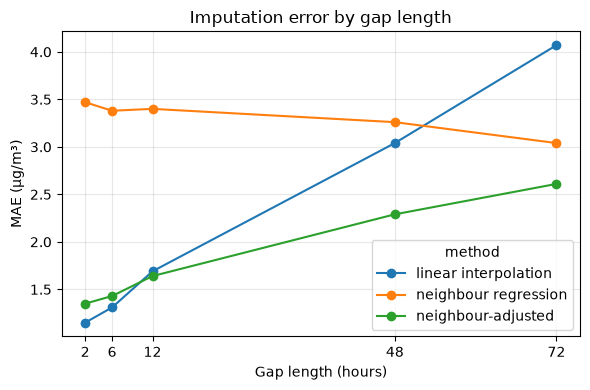

In [6]:
ax = val.plot(marker="o", figsize=(6, 4))
ax.set(xlabel="Gap length (hours)", ylabel="MAE (µg/m³)", title="Imputation error by gap length", xticks=val.index)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "imputation_error.png", dpi=150)
plt.show()

Rule chosen from the validation:
- 1 to 6 h: linear interpolation
- 7 to 72 h: neighbour-adjusted interpolation (left missing if no neighbour covers the gap)
- longer than 72 h, or all 3 stations down: left missing

`imputed` marks filled hours: model inputs only, never scoring targets. `pm25_raw` keeps the measured value for scoring.

In [7]:
filled = pm.copy()
imputed = pd.DataFrame(False, index=pm.index, columns=STATIONS)
for s in STATIONS:
    col = filled.columns.get_loc(s)
    v = pm[s].to_numpy()
    for a, n in gap_runs(pm[s]):
        if n <= 6:
            fill = linear_fill(v, a, n)
        elif n <= 72:
            fill = neighbour_adjusted(pm, s, a, n)
        else:
            fill = None
        if fill is not None:
            filled.iloc[a: a + n, col] = fill
            imputed.iloc[a: a + n, col] = True

before, after = missing_by_year(pm_raw), missing_by_year(filled)
pd.concat({"missing % before": before, "missing % after": after}, axis=1)

missing % before                 missing % after                
                 stou mineral highway            stou mineral highway
time                                                                 
2022              7.7     6.8     7.4             4.8     4.4     4.4
2023             17.8    17.2    20.4            15.1    15.2    15.2
2024             16.5    17.4    17.9             2.8     4.4     3.1

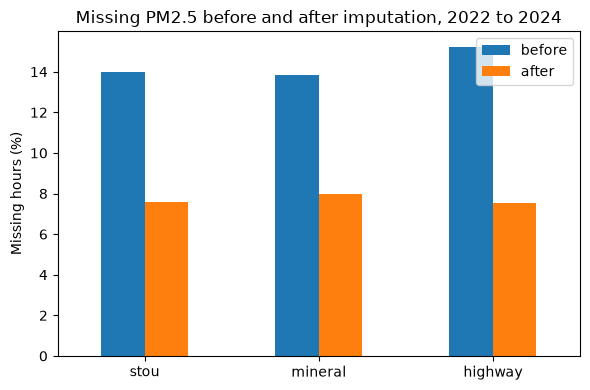

In [8]:
ax = pd.DataFrame({"before": pm_raw.isna().mean() * 100, "after": filled.isna().mean() * 100}).plot.bar(figsize=(6, 4), rot=0)
ax.set(ylabel="Missing hours (%)", title="Missing PM2.5 before and after imputation, 2022 to 2024")
plt.tight_layout()
plt.savefig(FIG / "missing_before_after.png", dpi=150)
plt.show()

## 4. Weather
Archived forecasts, UTC to Bangkok. Wind direction is circular (359° sits next to 0°), so encode it as sin and cos.

In [9]:
weather = {}
for s in STATIONS:
    w = load_utc(RAW / "weather" / f"{s}.csv").reindex(INDEX)
    rad = np.radians(w.pop("wind_direction_10m"))
    w["wind_dir_rad"] = rad  # kept for the fire weighting below
    w["wind_sin"], w["wind_cos"] = np.sin(rad), np.cos(rad)
    weather[s] = w
print(weather["stou"].isna().sum().sum(), "missing weather values")
weather["stou"].head(3)

49 missing weather values


,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,wind_dir_rad,wind_sin,wind_cos
time,,,,,,,
2022-01-01 00:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 01:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-01 02:00:00+07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Fire features

- VIIRS confidence nominal or high only; within 500 km of Bangkok.
- FIRMS `acq_date` + `acq_time` are UTC; a detection at 13:30 becomes usable from 14:00 (rounded up), so no hour sees a fire detected after it.
- Counts and FRP per ring (0 to 100, 100 to 300, 300 to 500 km) over the previous 24, 48 and 72 hours.
- Wind-weighted count: each fire weighted by how directly it lies upwind of Bangkok, using that hour's forecast wind. Done with 16 compass sectors so it stays fast.

In [10]:
fires = pd.concat(pd.read_csv(p) for p in sorted((RAW / "firms").glob("*.csv")))
n_all = len(fires)
fires = fires[fires.confidence.isin(["n", "h"])]

lat1, lon1 = np.radians(BKK_LAT), np.radians(BKK_LON)
lat2, lon2 = np.radians(fires.latitude), np.radians(fires.longitude)
fires["dist_km"] = 6371 * 2 * np.arcsin(np.sqrt(
    np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2))
fires["bearing"] = np.arctan2(np.sin(lon2 - lon1) * np.cos(lat2),
                              np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lon2 - lon1)) % (2 * np.pi)
fires = fires[fires.dist_km <= 500]

utc = pd.to_datetime(fires.acq_date + fires.acq_time.astype(str).str.zfill(4), format="%Y-%m-%d%H%M", utc=True)
fires["available"] = utc.dt.ceil("h").dt.tz_convert(TZ)
fires = fires[fires.available.between(INDEX[0], INDEX[-1])]
print(f"{n_all:,} detections -> {len(fires):,} after confidence, 500 km and date filters")

2,296,906 detections -> 381,199 after confidence, 500 km and date filters


In [11]:
fire_feat = pd.DataFrame(index=INDEX)
rings = {"r0_100": (0, 100), "r100_300": (100, 300), "r300_500": (300, 500)}
for name, (lo, hi) in rings.items():
    f = fires[(fires.dist_km > lo) & (fires.dist_km <= hi)]
    count = f.groupby("available").size().reindex(INDEX, fill_value=0)
    frp = f.groupby("available")["frp"].sum().reindex(INDEX, fill_value=0)
    for hours in [24, 48, 72]:
        fire_feat[f"fire_n_{name}_{hours}h"] = count.rolling(hours, min_periods=1).sum()
        fire_feat[f"fire_frp_{name}_{hours}h"] = frp.rolling(hours, min_periods=1).sum()

# hourly counts per 22.5 degree sector, summed over the previous 48 h
fires["sector"] = (fires.bearing // (2 * np.pi / 16)).astype(int)
sector_counts = (fires.groupby(["available", "sector"]).size().unstack(fill_value=0)
                 .reindex(index=INDEX, columns=range(16), fill_value=0)
                 .rolling(48, min_periods=1).sum())
sector_centres = (np.arange(16) + 0.5) * 2 * np.pi / 16

def wind_weighted(wind_dir_rad):
    # wind direction is where wind comes FROM; a fire on that bearing is upwind
    w = np.clip(np.cos(sector_centres[None, :] - wind_dir_rad.to_numpy()[:, None]), 0, None)
    return pd.Series((sector_counts.to_numpy() * w).sum(axis=1), index=INDEX)

fire_feat.describe().T[["mean", "max"]].head(6)

,mean,max
fire_n_r0_100_24h,11.487264,174.00
fire_frp_r0_100_24h,58.824062,1312.05
fire_n_r0_100_48h,22.946966,197.00
fire_frp_r0_100_48h,117.534736,1415.39
fire_n_r0_100_72h,34.380512,238.00
fire_frp_r0_100_72h,176.146399,2085.69


## 6. Merge and save
One row per station and hour. CAMS PM2.5 is kept as a baseline column, not a model input.

In [12]:
frames = []
for s in STATIONS:
    cams = load_utc(RAW / "cams" / f"{s}.csv")["pm2_5"].reindex(INDEX)
    w = weather[s]
    df = pd.DataFrame({
        "station": s,
        "pm25": filled[s],
        "pm25_raw": pm_raw[s].mask(removed[s] | (pm_raw[s] <= 0)),
        "imputed": imputed[s],
        "cams_pm25": cams,
    }, index=INDEX)
    df = df.join(w.drop(columns="wind_dir_rad")).join(fire_feat)
    df["fire_upwind_48h"] = wind_weighted(w["wind_dir_rad"])
    frames.append(df)

hourly = pd.concat(frames).reset_index()
hourly.to_csv(CLEAN / "hourly.csv", index=False)
print(f"saved {CLEAN / 'hourly.csv'}: {hourly.shape[0]:,} rows x {hourly.shape[1]} columns")
hourly.isna().mean().mul(100).round(1).loc[lambda s: s > 0].rename("missing %")

saved data/clean/hourly.csv: 78,912 rows x 31 columns


pm25          7.7
pm25_raw     14.4
cams_pm25    19.6
Name: missing %, dtype: float64